<a href="https://colab.research.google.com/github/haruyama8940/change_cmd/blob/main/carrotpath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

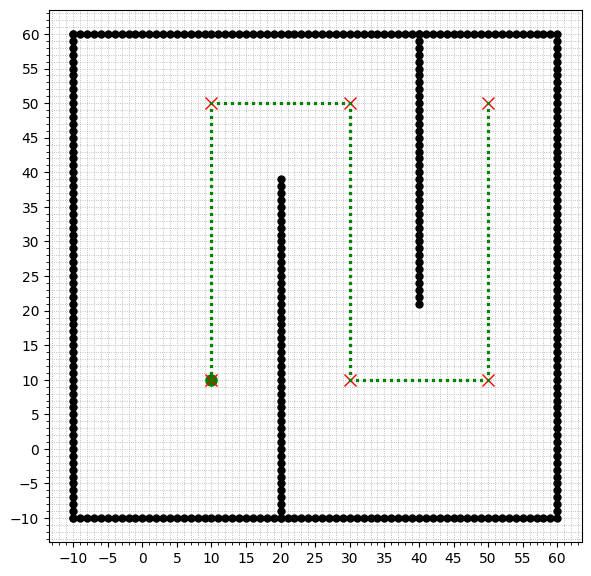

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

def calc_line(x1,x2,y1,y2,step_size=1.0):
    forward_vec = np.array([x2 - x1,y2-y1])
    length = np.hypot(x2-x1, y2-y1)
    u_vec = np.array([forward_vec[0]/length, forward_vec[1]/length])
    sample_num = int(length/step_size)
    path_points = np.zeros((sample_num,2))
    for i in range(sample_num):
        # path_points[i] = np.array([x1 + u_vec[0]*i*step_size, y1 + u_vec[1]*i*step_size]) #方向ベクトル＋sizeでずらす
        path_points[i,0] = x1 + u_vec[0]*i*step_size
        path_points[i,1] = y1 + u_vec[1]*i*step_size
    path_points = np.vstack([path_points, [x2, y2]])
    return path_points

def main():

    sx, sy = 10.0, 10.0
    gx, gy = 50.0, 50.0
    goal_list = np.array([[sx,sy],[10,50],[30,50],[30,10],[50,10],[50,50]])
    grid_size = 5.0
    robot_radius = 1.0

    # --- 障害物 ---
    ox, oy = [], []
    for i in range(-10, 60):      ox.append(i);  oy.append(-10.0)
    for i in range(-10, 60):      ox.append(60.0); oy.append(i)
    for i in range(-10, 61):      ox.append(i);  oy.append(60.0)
    for i in range(-10, 61):      ox.append(-10.0); oy.append(i)
    for i in range(-10, 40):      ox.append(20.0); oy.append(i)
    for i in range(0, 40):        ox.append(40.0); oy.append(60.0 - i)


    # --- 描画 ---------------------------------------------------------
    plt.figure(figsize=(6, 6))

    # 障害物・スタート・ゴール
    plt.plot(ox, oy, ".k", markersize=10)   # 壁
    plt.plot(sx, sy, "og", markersize=8)   # スタート
    # plt.plot(gx, gy, "xb", markersize=8)   # ゴール
    for i in range(goal_list.shape[0]):
      plt.plot(goal_list[i,0], goal_list[i,1], "xr", markersize=8)
    for i in range(goal_list.shape[0]-1):
      path_points = calc_line(goal_list[i,0],goal_list[i+1,0],goal_list[i,1],goal_list[i+1,1],step_size=1.0)
      plt.plot(path_points[:,0],path_points[:,1],"xg",markersize=2)
    # グリッド線と目盛り
    ticks = np.arange(-10, 62, grid_size)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.grid(which="both", linestyle=":", linewidth=0.6)
    plt.minorticks_on()

    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


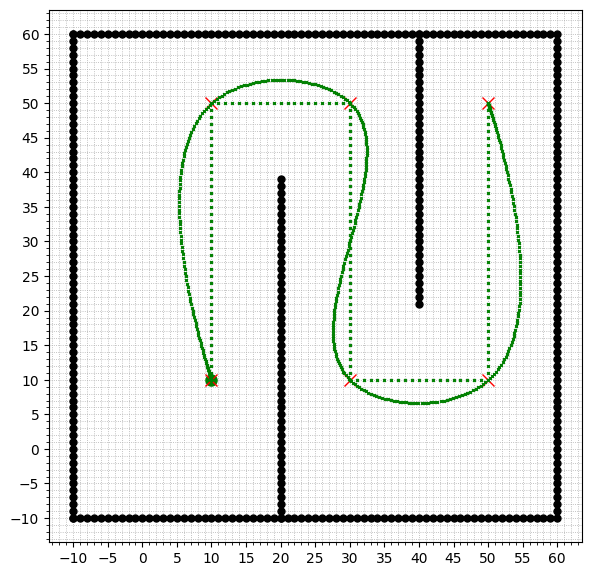

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline
def calc_line(x1,x2,y1,y2,step_size=1.0):
    forward_vec = np.array([x2 - x1,y2-y1])#方向ベクトル
    length = np.hypot(x2-x1, y2-y1)#2点間の距離
    u_vec = np.array([forward_vec[0]/length, forward_vec[1]/length])#単位方向ベクトル
    sample_num = int(length/step_size)
    path_points = np.zeros((sample_num,2))
    for i in range(sample_num):
        # path_points[i] = np.array([x1 + u_vec[0]*i*step_size, y1 + u_vec[1]*i*step_size]) #方向ベクトル＋sizeでずらす
        path_points[i,0] = x1 + u_vec[0]*i*step_size
        path_points[i,1] = y1 + u_vec[1]*i*step_size
    path_points = np.vstack([path_points, [x2, y2]])
    return path_points
# def calc_spline():

def main():

    sx, sy = 10.0, 10.0
    gx, gy = 50.0, 50.0
    goal_list = np.array([[sx,sy],[10,50],[30,50],[30,10],[50,10],[50,50]])
    grid_size = 5.0
    robot_radius = 1.0

    # --- 障害物 ---
    ox, oy = [], []
    for i in range(-10, 60):      ox.append(i);  oy.append(-10.0)
    for i in range(-10, 60):      ox.append(60.0); oy.append(i)
    for i in range(-10, 61):      ox.append(i);  oy.append(60.0)
    for i in range(-10, 61):      ox.append(-10.0); oy.append(i)
    for i in range(-10, 40):      ox.append(20.0); oy.append(i)
    for i in range(0, 40):        ox.append(40.0); oy.append(60.0 - i)


    # --- 描画 ---------------------------------------------------------
    plt.figure(figsize=(6, 6))

    # 障害物・スタート・ゴール
    plt.plot(ox, oy, ".k", markersize=10)   # 壁
    plt.plot(sx, sy, "og", markersize=8)   # スタート
    # plt.plot(gx, gy, "xb", markersize=8)   # ゴール
    for i in range(goal_list.shape[0]):
      plt.plot(goal_list[i,0], goal_list[i,1], "xr", markersize=8)
    for i in range(goal_list.shape[0]-1):
      path_points = calc_line(goal_list[i,0],goal_list[i+1,0],goal_list[i,1],goal_list[i+1,1],step_size=1.0)
      plt.plot(path_points[:,0],path_points[:,1],"xg",markersize=2)

    s = np.zeros(len(goal_list))        # s0 = 0
    s[1:] = np.cumsum(               # 各区間の長さを足し上げ
    np.linalg.norm(np.diff(goal_list, axis=0), axis=1))
    cs_x = CubicSpline(s, goal_list[:,0], bc_type='clamped')
    cs_y = CubicSpline(s, goal_list[:,1], bc_type='clamped')

    ts = np.linspace(0, s[-1], 400)
    xs, ys = cs_x(ts), cs_y(ts)

    plt.plot(xs, ys, "xg", markersize=2)
    # グリッド線と目盛り
    ticks = np.arange(-10, 62, grid_size)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.grid(which="both", linestyle=":", linewidth=0.6)
    plt.minorticks_on()

    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
